In [7]:
install.packages('elevatr')
install.packages('rayshader')

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

also installing the dependencies ‘tiff’, ‘spacefillr’, ‘RcppThread’, ‘decido’, ‘doParallel’, ‘terrainmeshr’, ‘rayimage’, ‘rayvertex’, ‘rayrender’


Warning message in install.packages("rayshader"):
“installation of package ‘tiff’ had non-zero exit status”
Warning message in install.packages("rayshader"):
“installation of package ‘spacefillr’ had non-zero exit status”
Warning message in install.packages("rayshader"):
“installation of package ‘RcppThread’ had non-zero exit status”
Warning message in install.packages("rayshader"):
“installation of package ‘decido’ had non-zero exit status”
Warning message in install.packages("rayshader"):
“installation of package ‘terrainmeshr’ had non-zero exit status”
Warning message in install.packages("rayshader"):
“installation of package ‘rayimage’ had non-zero exit status”
Warning message in install.packages("rayshader"):
“installation of package ‘rayvertex’ had non-ze

In [3]:
library(ggplot2)
library(sf)
library(raster)
library(terra)
library(rnaturalearth)
library(rnaturalearthdata)
library(elevatr)
#library(rayshader)

Linking to GEOS 3.12.1, GDAL 3.8.5, PROJ 9.4.0; sf_use_s2() is TRUE

Loading required package: sp

terra 1.7.78


Attaching package: ‘rnaturalearthdata’


The following object is masked from ‘package:rnaturalearth’:

    countries110


elevatr v0.99.0 NOTE: Version 0.99.0 of 'elevatr' uses 'sf' and 'terra'.  Use 
of the 'sp', 'raster', and underlying 'rgdal' packages by 'elevatr' is being 
deprecated; however, get_elev_raster continues to return a RasterLayer.  This 
will be dropped in future versions, so please plan accordingly.



In [86]:
# Custom hillshade function
calculate_hillshade <- function(elevation_raster, azimuth = 315, altitude = 45) {
  # Convert to terra raster if needed
  if (class(elevation_raster)[1] == "RasterLayer") {
    elevation_raster <- rast(elevation_raster)
  }
  
  # Calculate slope and aspect
  slope_rad <- terrain(elevation_raster, "slope", unit = "radians")
  aspect_rad <- terrain(elevation_raster, "aspect", unit = "radians")
  
  # Convert azimuth and altitude to radians
  azimuth_rad <- (azimuth - 90) * pi / 180
  altitude_rad <- altitude * pi / 180
  
  # Calculate hillshade using the standard formula
  # hillshade = sin(altitude) * sin(slope) + cos(altitude) * cos(slope) * cos(azimuth - aspect)
  hillshade <- sin(altitude_rad) * sin(slope_rad) + 
               cos(altitude_rad) * cos(slope_rad) * cos(azimuth_rad - aspect_rad)
  
  # Normalize to 0-1 range
  hillshade_norm <- (hillshade + 1) / 2
  
  return(hillshade_norm)
}

# Alternative custom hillshade function with more control
calculate_hillshade_advanced <- function(elevation_raster, azimuth = 315, altitude = 45, 
                                       z_factor = 1, scale_factor = 1) {
  # Convert to terra raster if needed
  if (class(elevation_raster)[1] == "RasterLayer") {
    elevation_raster <- rast(elevation_raster)
  }
  
  # Apply z-factor for vertical exaggeration
  elev_scaled <- elevation_raster * z_factor
  
  # Calculate gradients using focal operations
  # 3x3 kernel for slope calculation
  dx_kernel <- matrix(c(-1, 0, 1, -2, 0, 2, -1, 0, 1), nrow = 3) / 8
  dy_kernel <- matrix(c(-1, -2, -1, 0, 0, 0, 1, 2, 1), nrow = 3) / 8
  
  # Calculate gradients
  dx <- focal(elev_scaled, dx_kernel, na.rm = TRUE)
  dy <- focal(elev_scaled, dy_kernel, na.rm = TRUE)
  
  # Calculate slope and aspect
  slope_rad <- atan(sqrt(dx^2 + dy^2) * scale_factor)
  aspect_rad <- atan2(dy, -dx)
  
  # Convert sun position to radians
  azimuth_rad <- (azimuth - 90) * pi / 180
  altitude_rad <- altitude * pi / 180
  
  # Calculate hillshade
  hillshade <- sin(altitude_rad) * sin(slope_rad) + 
               cos(altitude_rad) * cos(slope_rad) * cos(azimuth_rad - aspect_rad)
  
  # Normalize and enhance contrast
  hillshade_norm <- pmax(0, pmin(1, (hillshade + 1) / 2))
  
  return(hillshade_norm)
}

In [87]:
# Define your custom extent (example for Alaska/Western Canada)
extent_coords <- c(xmin = -170, xmax = -120, ymin = 55, ymax = 72)

# Set up an equal area projection suitable for Alaska/Canada
crs_albers <- "+proj=aea +lat_1=55 +lat_2=65 +lat_0=50 +lon_0=-154 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs"

# Get country boundaries
world <- ne_countries(scale = "medium", returnclass = "sf")
alaska_canada <- world[world$name_en %in% c("United States of America", "Canada"), ]

In [88]:
# FIXED: Create extent for get_elev_raster using different approaches

# Method 1: Use a simple data frame (recommended for get_elev_raster)
extent_df <- data.frame(
  x = c(extent_coords[1], extent_coords[2], extent_coords[2], extent_coords[1]),
  y = c(extent_coords[3], extent_coords[3], extent_coords[4], extent_coords[4])
)

# Method 2: Create extent as a simple vector (alternative)
# extent_vector <- c(extent_coords[1], extent_coords[3], extent_coords[2], extent_coords[4])

# Method 3: Create a proper sf polygon for cropping (separate from elevation)
extent_coords_matrix <- matrix(c(
  extent_coords[1], extent_coords[3],  # xmin, ymin
  extent_coords[1], extent_coords[4],  # xmin, ymax
  extent_coords[2], extent_coords[4],  # xmax, ymax
  extent_coords[2], extent_coords[3],  # xmax, ymin
  extent_coords[1], extent_coords[3]   # close polygon
), ncol = 2, byrow = TRUE)


extent_df = data.frame(extent_coords_matrix)
names(extent_df)=c('x','y')

head(extent_df)

,x,y
,<dbl>,<dbl>
1,-170,55
2,-170,72
3,-120,72
4,-120,55
5,-170,55


In [89]:
extent_poly <- st_polygon(list(extent_coords_matrix)) %>%
  st_sfc(crs = 4326)

# Method 1: Convert st_polygon to sf using st_sf()
extent_sf <- st_sf(
  id = 1,                    # Add attribute columns as needed
  name = "data_extent",    # Optional: add more attributes
  geometry = st_sfc(extent_poly, crs = 4326)  # Wrap in st_sfc and set CRS
)

In [90]:
head(extent_poly)

POLYGON ((-170 55, -170 72, -120 72, -120 55, -...



Geometry set for 1 feature 
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: -170 ymin: 55 xmax: -120 ymax: 72
Geodetic CRS:  WGS 84

In [91]:

# SET UP OPENTOPO API KEY
# Method 1: Set API key for current session
# Get your free API key from: https://cloud.sdsc.edu/v1/AUTH_opentopography/API/usageterms.html
opentopo_key <- '3d1e3c46a10346fcb37c180ec8a0fbdc'  # Replace with your actual key
Sys.setenv("OPENTOPO_KEY" = opentopo_key)

In [92]:
# data(lake)
# lake_buff  <- st_buffer(lake, 1000)
# loc_df <- data.frame(x = runif(6,min=sf::st_bbox(lake)$xmin, 
#                                max=sf::st_bbox(lake)$xmax),
#                      y = runif(6,min=sf::st_bbox(lake)$ymin, 
#                                max=sf::st_bbox(lake)$ymax))

In [93]:
# data(lake)
# lake_buff  <- st_buffer(lake, 1000)
# loc_df <- data.frame(x = runif(6,min=sf::st_bbox(lake)$xmin, 
#                                max=sf::st_bbox(lake)$xmax),
#                      y = runif(6,min=sf::st_bbox(lake)$ymin, 
#                                max=sf::st_bbox(lake)$ymax)
#                     )
                         
# x <- get_elev_raster(locations = loc_df, prj = st_crs(lake) , z=10)
# x <- get_elev_raster(lake, z = 12)
# x <- get_elev_raster(lake, src = "gl3", expand = 5000)
# x <- get_elev_raster(lake_buff, z = 10, clip = "locations")

In [103]:
# Crop and transform data
alaska_canada_crop <- st_crop(alaska_canada, extent_poly) %>%
  st_transform(crs_albers)

# Get elevation data
elevation_data <- get_elev_raster(land_polygons, z = 3, clip = "locations", override_size_check = TRUE)

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”
Mosaicing & Projecting

Clipping DEM to locations

Note: Elevation units are in meters.



In [104]:

elevation_terra <- rast(elevation_data)
elevation_proj <- project(elevation_terra, crs_albers)


In [73]:
# Function to clip raster by coastlines/land areas
clip_raster_by_land <- function(raster_data, land_polygons, mask_water = TRUE) {
  # Ensure both are in the same CRS
  if (st_crs(land_polygons) != crs(raster_data)) {
    land_polygons <- st_transform(land_polygons, crs(raster_data))
  }
  
  if (mask_water) {
    # Mask out water areas (keep only land)
    raster_clipped <- mask(raster_data, vect(land_polygons))
  } else {
    # Mask out land areas (keep only water)
    raster_clipped <- mask(raster_data, vect(land_polygons), inverse = TRUE)
  }
  
  return(raster_clipped)
}


In [74]:
# Alternative: Get land polygons for more precise masking
land_polygons <- ne_download(scale = "medium", type = "countries", returnclass = "sf")

Reading layer `ne_50m_admin_0_countries' from data source 
  `/tmp/RtmpQDbgMt/ne_50m_admin_0_countries.shp' using driver `ESRI Shapefile'
Simple feature collection with 242 features and 168 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -180 ymin: -89.99893 xmax: 180 ymax: 83.59961
Geodetic CRS:  WGS 84


In [108]:
# Crop land polygons to study area
cat("Cropping land polygons to study area...\n")
land_crop <- st_crop(land_polygons, extent_poly)

# Transform land polygons to projection
land_crop_proj <- st_transform(land_crop, crs_albers)

# CLIP HILLSHADE BY COASTLINES/LAND AREAS
cat("Clipping elev by coastlines...\n")
elevation_terra <- clip_raster_by_land(elevation_terra, land_crop, mask_water = TRUE)

Cropping land polygons to study area...


Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


Clipping elev by coastlines...


In [109]:

# Create hillshade using custom function
# You can experiment with different parameters:
# - azimuth: sun direction (0-360 degrees, 315 is northwest)
# - altitude: sun angle above horizon (0-90 degrees, 45 is common)
hillshade <- calculate_hillshade(elevation_terra, azimuth = 315, altitude = 15)

# Or use the advanced version for more control
# hillshade <- calculate_hillshade_advanced(elevation_proj, 
#                                         azimuth = 315, 
#                                         altitude = 45,
#                                         z_factor = 2,  # vertical exaggeration
#                                         scale_factor = 1)

# Reproject hillshade after everything
hillshade <- project(hillshade, crs_albers)

# Convert to data frame for ggplot
hillshade_df <- as.data.frame(hillshade, xy = TRUE)
names(hillshade_df) <- c("x", "y", "hillshade")
hillshade_df <- hillshade_df[!is.na(hillshade_df$hillshade), ]

Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”


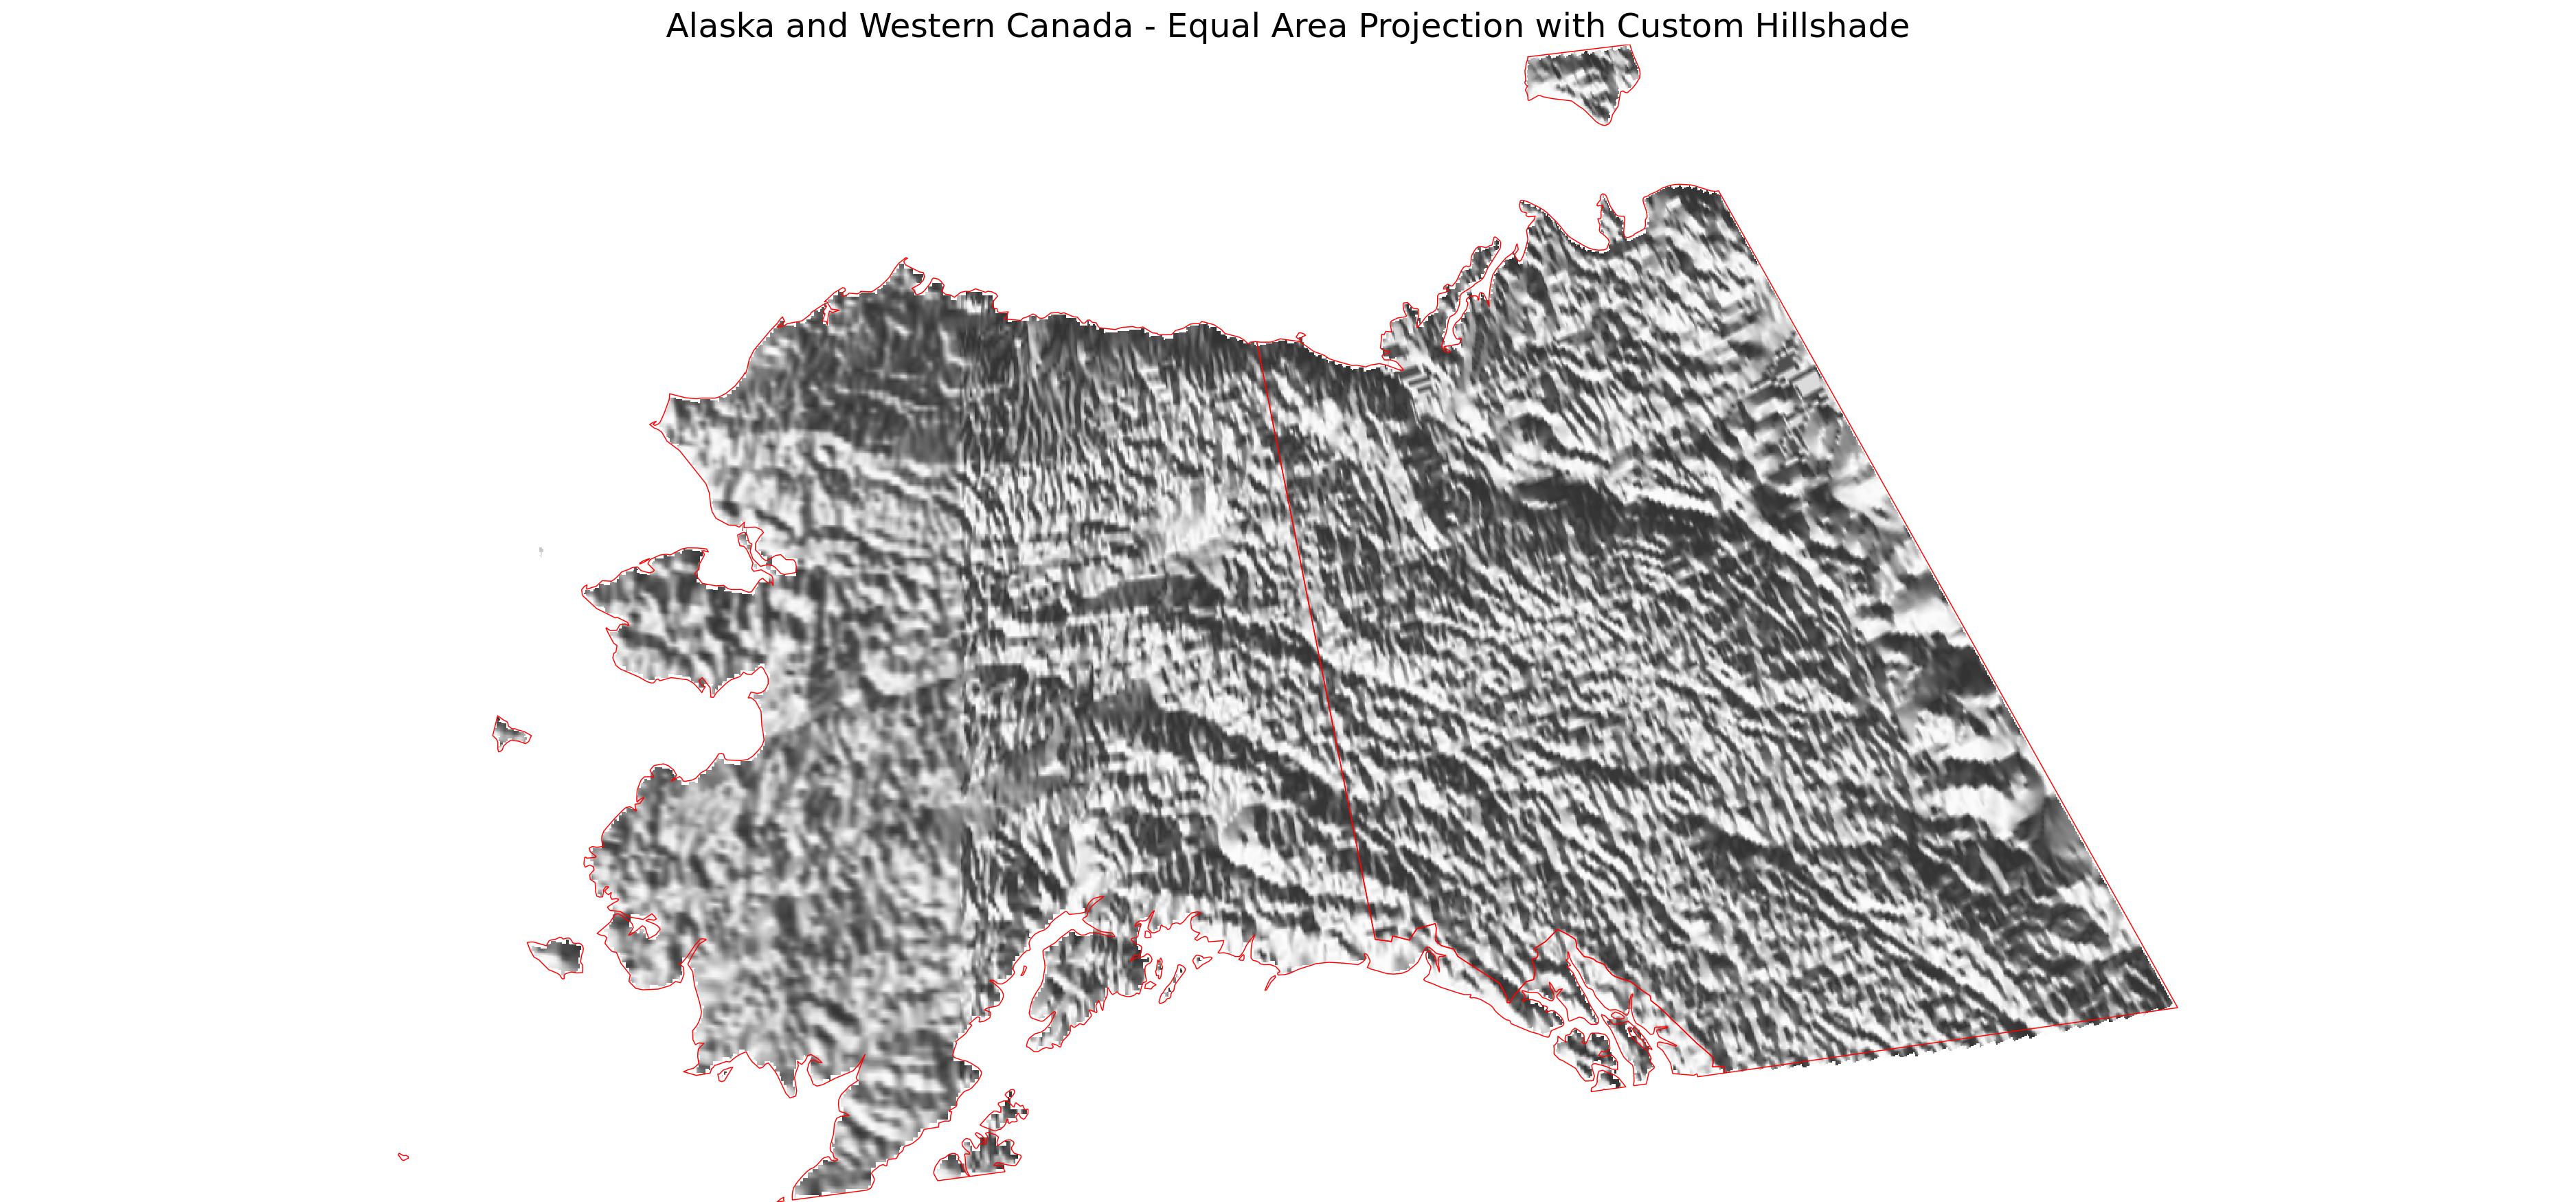

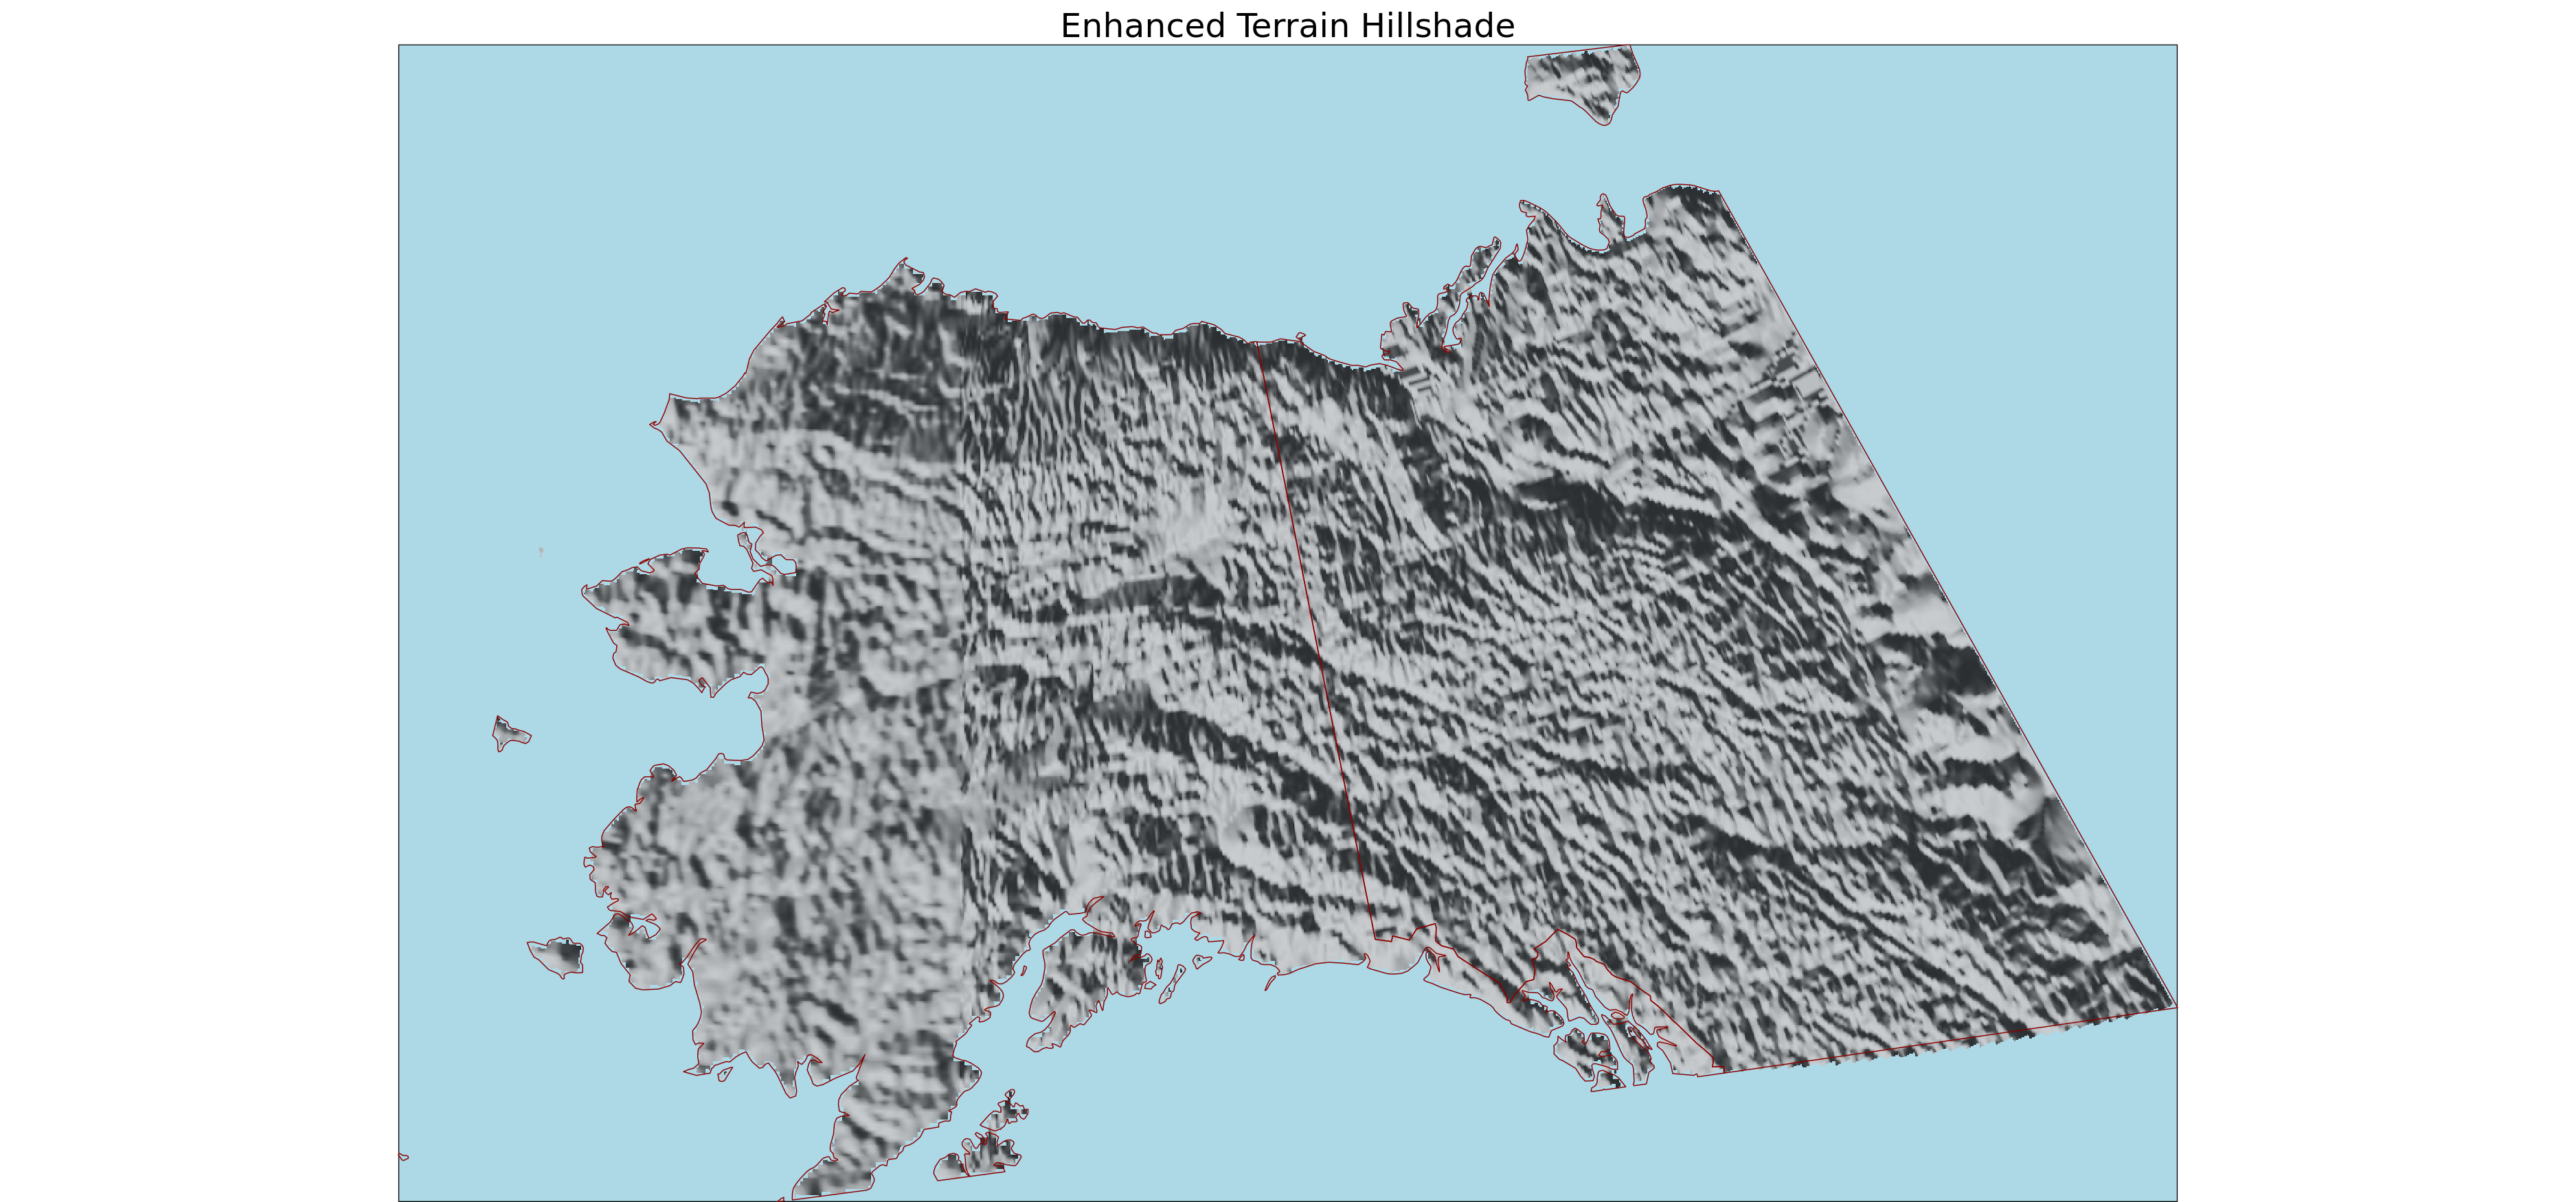

In [110]:
options(repr.plot.width = 15, repr.plot.height = 7, repr.plot.res = 250)

# Create the map
p <- ggplot() +
  # Add hillshade as base layer
  geom_raster(data = hillshade_df, 
              aes(x = x, y = y, fill = hillshade)
              ,alpha = 0.8
             ) +
  scale_fill_gradient(low = "black", high = "white", guide = "none") +
  
  # Add country boundaries
  geom_sf(data = alaska_canada_crop, 
          fill = NA, 
          color = "red", 
          size = 0.8) +
  
  # Set coordinate system and extent
  coord_sf(crs = crs_albers, 
           expand = FALSE) +
  
  # Styling
  theme_void() +
  theme(
    #panel.background = element_rect(fill = "lightblue"),
    plot.title = element_text(hjust = 0.5, size = 14)
  ) +
  labs(title = "Alaska and Western Canada - Equal Area Projection with Custom Hillshade")

print(p)

# Optional: Create a version with enhanced terrain colors
p_enhanced <- ggplot() +
  # Add hillshade with terrain colors
  geom_raster(data = hillshade_df, 
              aes(x = x, y = y, fill = hillshade), 
              alpha = 0.9) +
  scale_fill_gradient2(low = "grey10", mid = "grey60", high = "grey80", 
                       midpoint = 0.5, guide = "none") +
  
  # Add country boundaries
  geom_sf(data = alaska_canada_crop, 
          fill = NA, 
          color = "darkred", 
          size = 1) +
  
  coord_sf(crs = crs_albers, expand = FALSE) +
  
  theme_void() +
  theme(
    panel.background = element_rect(fill = "lightblue"),
    plot.title = element_text(hjust = 0.5, size = 14)
  ) +
  labs(title = "Enhanced Terrain Hillshade")

print(p_enhanced)

Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”
Warning message:
“Raster pixels are placed at uneven horizontal intervals and will be shifted
ℹ Consider using `geom_tile()` instead.”


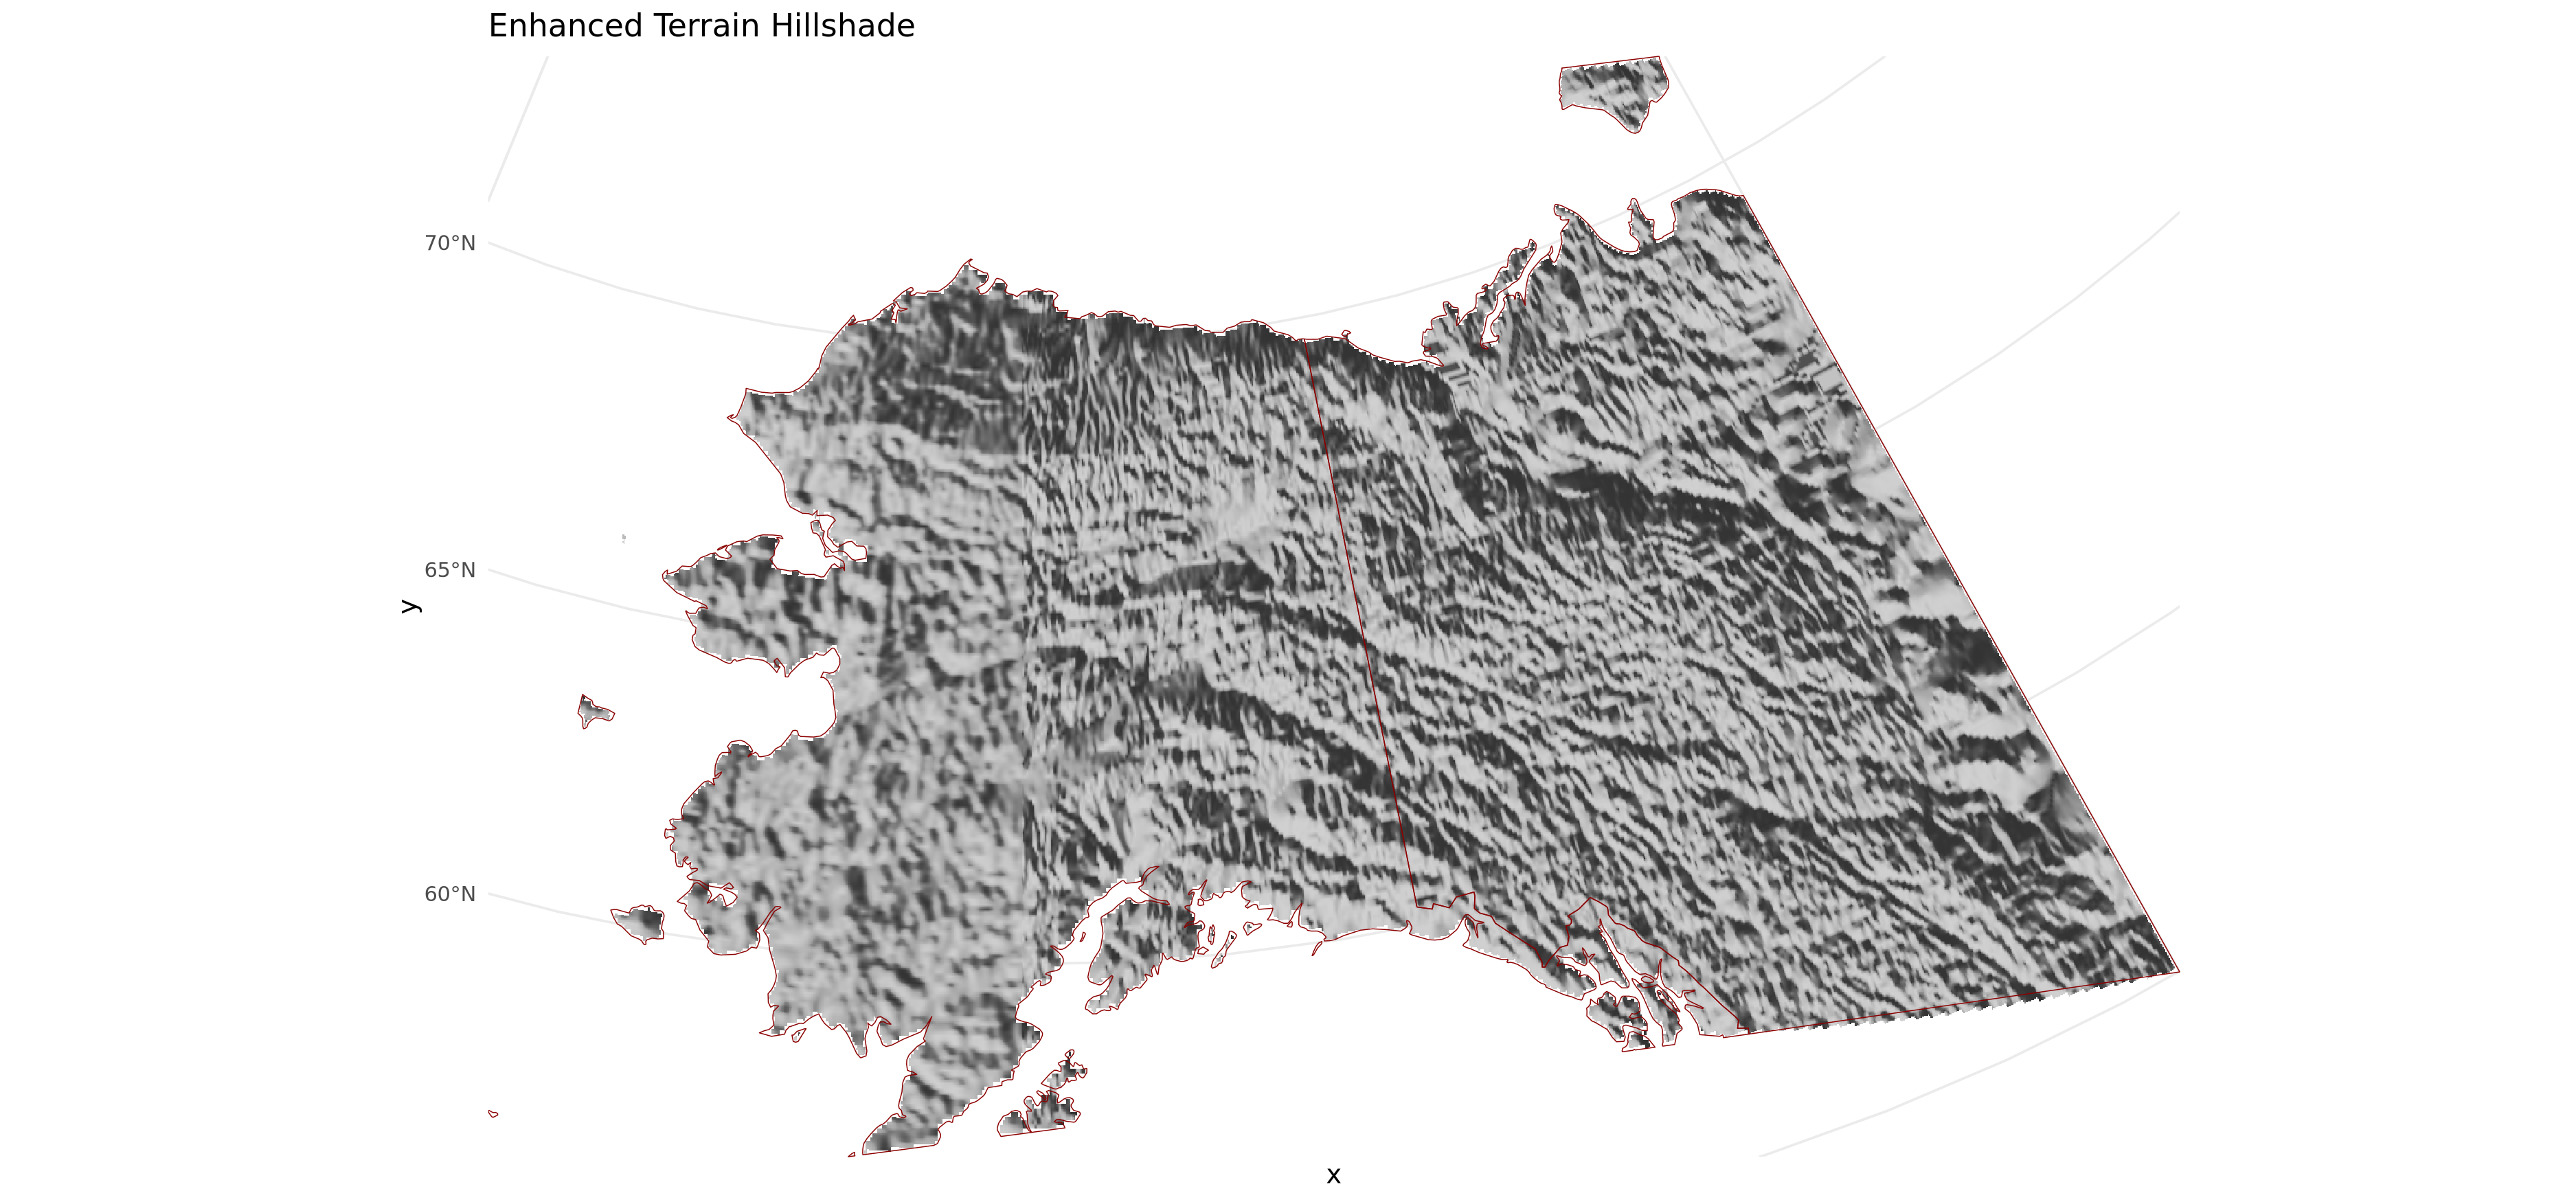

In [111]:
print(p_enhanced + theme_minimal())